# Part 2 - EDA para Starved Lubrication

[![](https://mermaid.ink/img/pako:eNqNU-9vmzAQ_Vcs90srkQySmAY-VOrWRqq0H1EzadIgqhw4gzWCkTFquzT_-44EKKSbVkuAjd97vnd33tFIxUB9KjL1GKVcG_L5PtRhTnCU1SbRvEjJQhoS4Gvd7tQjlhoiI1XeY9Rj8XCXF5UJPnITpUQJcg8CNOQRkJVMcp6VazIaXSHu9sloHpmg-ZK7XCi95bXmeqjYIo68HyCT1JTB-cooDTFp1hcdCfK4nr7xsUS0RJmgmbzLz_LUz8DF8mHFt0UGwSrCWMgtR8wRsB6KHGEN5zpJAnw0JNxgWmpqeYLH7Qb8rTLnwXUG2vjku66AfCALPB_WF__w22WIjMajq5cvWOGsTdJLF0qfEWW8LG9AEFlb_YoEImSW-WfgCCbAKo1Wv8A_sx126W2a5ehRxib1J8XTG5lCqwjKsickhJiC3QmByxzb_r9QiRXmCfQjmgsGXifkbBhM3iGkKjN0huEwwTqdGXdm8-ivOgOttr2tpi1eM3YKa3rWavNtHWvaS80po61az_QQcuiFnhVq0UTLmPoG28KiW8DbUy_prmaF1KSwhZD6OI1B8CozIQ3zPdIKnv9UatsytaqSlPqibiuLVkWMbXkjOd6aVwg2GehPqsoN9Z35QYL6O_pE_ak9G7su86aMMdueTD2LPuNfd-xMZt7cmXq2PXNdb2_R34cz7fH8ku3_AFlTedc?type=png)](https://mermaid.live/edit#pako:eNqNU-9vmzAQ_Vcs90srkcxAIIEPlbq1kSrtR9RMmjSIKgfOgEYwMkbtluZ_35EAg3TTagmw8XvP9-7OexrJGKhPRS6fopQrTT4-hCosCI6q3iaKlylZZpoE-Np0O82IMwWRzmQxYDRj-XhflLUO3nMdpUQK8gACFBQRkHWWFDyvNmQyuUbc3bNWPNJB-yX3hZBqxxvNzVixQ5x43yBLUl0Fl2stFcSkXV_1JCjiZvrKxwrRGcoE7eRNflbnfkYuVo9rvitzCNYRxkLuOGJOgM1Y5ARrOTdJEuCjIOEa09JQqzM8brfgL7W-DG5yUNonX1UN5B1Z4vmwufqH3z5DZDKdXL98wgrnXZJe-lCGjCjnVXULgmSN1c9IICLLc_8CTOEIMCqt5A_wL5jpzL1tu5w8ZbFOfat8fiVTKhlBVQ2EhBA2sF4IXMdk7P9CFVaYJzCMaCEc8Hohc-uA9QYhWeuxMwzHEU6vM-PmbBH9VWek1bW30bbFn4ydw9qeNbp8G6eaDlJzzuiqNjA9hhx7YWCFGjRRWUx9jW1h0B3g7WmWdN-wQqpT2EFIfZzGIHid65CGxQFpJS--S7nrmErWSUp90bSVQesyxra8zTjeml3_F69wDOqDrAtNfdM-alB_T5-pb7PZ1HUdz3YchzHL9gz6E_-6U9OaeQvT9hibua53MOiv46FsupgjEKEum8-Z5ViH3xZpfKw)

O desafio ja fixa a regra final de decisao dentro de `LubricationModel.predict`:

```python
np.percentile(scores, 75) > 0.75
```

O objetivo vai sercriar um `predict_sample(wave)`, que devolve um score entre 0 e 1 para cada sinal individual.

In [2]:
# Imports

from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import signal, stats

warnings.filterwarnings('ignore', category=FutureWarning)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (13, 4)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10

SEMENTE = 42
FREQ_MINIMA_CARPET_HZ = 1000.0
EPS = 1e-12
MAX_SINAIS_POR_SPLIT_FEATURES = 20  # use None para processar todos os sinais de cada fit/predict


def encontrar_raiz_do_projeto():
    atual = Path.cwd().resolve()
    for candidato in [atual, *atual.parents]:
        if (candidato / 'pyproject.toml').exists() and (candidato / 'src').exists():
            return candidato
    return atual


RAIZ = encontrar_raiz_do_projeto()
CANDIDATOS_PART2 = [RAIZ / 'source' / 'part2', RAIZ / 'data' / 'part2']
PASTA_PART2 = next((p for p in CANDIDATOS_PART2 if (p / 'labels.csv').exists()), None)

if PASTA_PART2 is None:
    raise FileNotFoundError(f'Dados da Part 2 nao encontrados em: {CANDIDATOS_PART2}')

PASTA_ASSETS = PASTA_PART2 / 'assets'
PASTA_TESTE = PASTA_PART2 / 'test_data'

print('Raiz do projeto:', RAIZ)
print('Dados da Part 2:', PASTA_PART2)


Raiz do projeto: C:\Users\vinicius\Documents\MEUGITHUB\Vibration_challenge
Dados da Part 2: C:\Users\vinicius\Documents\MEUGITHUB\Vibration_challenge\source\part2


In [3]:
# Leitura dos Labels e dos dados.

labels = pd.read_csv(PASTA_PART2 / 'labels.csv')
labels['asset_id'] = labels['asset_id'].astype(str)
labels['is_starved'] = labels['label'].str.lower().str.contains('starved')

asset_dirs = sorted([p for p in PASTA_ASSETS.iterdir() if p.is_dir()])
test_dirs = sorted([p for p in PASTA_TESTE.iterdir() if p.is_dir()])

ids_label = set(labels['asset_id'])
ids_assets = {p.name for p in asset_dirs}
ids_teste = {p.name for p in test_dirs}

print('Assets com label:', len(labels))
print('Pastas em assets:', len(asset_dirs))
print('Pastas em test_data:', len(test_dirs))
print('Assets em assets sem label:', len(ids_assets - ids_label))
print('Labels sem pasta em assets:', len(ids_label - ids_assets))
print('Distribuicao dos labels:')
display(labels['label'].value_counts().rename('quantidade').to_frame())

if ids_assets - ids_label:
    print('Exemplos de pastas em assets sem label:', sorted(ids_assets - ids_label)[:5])


Assets com label: 144
Pastas em assets: 146
Pastas em test_data: 20
Assets em assets sem label: 2
Labels sem pasta em assets: 0
Distribuicao dos labels:


,quantidade
label,
healthy,96
starved lubrication,48


Exemplos de pastas em assets sem label: ['test 6864339ebf3fa7dcb33fd51b', 'test 689e4e90dc68b26704d071d6']


In [4]:
# Funções auxiliares para features e inventário.
def resumo_npz(caminho):
    npz = np.load(caminho, allow_pickle=False)
    data = npz['data']
    dt = npz['dt']
    sample_ids = npz['sample_ids']
    return {
        'n_sinais': int(data.shape[0]),
        'tamanho_sinal': int(data.shape[1]),
        'dt_min': float(np.min(dt)),
        'dt_max': float(np.max(dt)),
        'fs_mediana': float(np.median(1.0 / dt)),
        'duracao_mediana_s': float(np.median((data.shape[1] - 1) * dt)),
        'sample_ids': int(len(sample_ids)),
    }


linhas_inventario = []
for asset_dir in asset_dirs:
    for split in ['fit', 'predict']:
        resumo = resumo_npz(asset_dir / f'{split}.npz')
        resumo['asset_id'] = asset_dir.name
        resumo['split'] = split
        linhas_inventario.append(resumo)

inventario = pd.DataFrame(linhas_inventario)
inventario = inventario.merge(labels[['asset_id', 'label', 'is_starved']], on='asset_id', how='left')

display(inventario.head())

,n_sinais,tamanho_sinal,dt_min,dt_max,fs_mediana,duracao_mediana_s,sample_ids,asset_id,split,label,is_starved
0,60,32000,0.000063,0.000063,16000.0,1.999938,60,04564901-7070-40b3-9498-baa86a57d90b,fit,starved lubrication,True
1,30,32000,0.000063,0.000063,16000.0,1.999938,30,04564901-7070-40b3-9498-baa86a57d90b,predict,starved lubrication,True
2,60,32000,0.000063,0.000063,16000.0,1.999938,60,07405721-f9bd-4664-97f3-dcd7ed20cd12,fit,healthy,False
3,30,32000,0.000063,0.000063,16000.0,1.999938,30,07405721-f9bd-4664-97f3-dcd7ed20cd12,predict,healthy,False
4,60,32000,0.000063,0.000063,16000.0,1.999938,60,08315749-86f9-4960-8a17-5be18217dd25,fit,healthy,False


In [5]:
display(inventario.groupby('split')[['n_sinais', 'tamanho_sinal', 'fs_mediana', 'duracao_mediana_s']].describe().round(3))

n_sinais                                              tamanho_sinal  \
           count    mean    std   min   25%   50%   75%   max         count   
split                                                                         
fit        146.0  60.233  2.247  60.0  60.0  60.0  60.0  86.0         146.0   
predict    146.0  30.185  1.661  30.0  30.0  30.0  30.0  48.0         146.0   

                  ... fs_mediana          duracao_mediana_s              \
            mean  ...        75%      max             count mean    std   
split             ...                                                     
fit      32000.0  ...    16000.0  16229.0             146.0  2.0  0.003   
predict  32000.0  ...    16000.0  16229.0             146.0  2.0  0.003   

                                      
           min  25%  50%  75%    max  
split                                 
fit      1.972  2.0  2.0  2.0  2.027  
predict  1.972  2.0  2.0  2.0  2.027  

[2 rows x 32 columns]

In [6]:
asset_healthy = labels.loc[~labels['is_starved'], 'asset_id'].iloc[0]
asset_starved = labels.loc[labels['is_starved'], 'asset_id'].iloc[0]

print('Asset healthy:', asset_healthy)
print('Asset starved:', asset_starved)


def carregar_npz(asset_id, split, base_dir=PASTA_ASSETS):
    caminho = base_dir / asset_id / f'{split}.npz'
    npz = np.load(caminho, allow_pickle=False)
    return {
        'data': npz['data'].astype(np.float64),
        'dt': npz['dt'].astype(np.float64),
        'sample_ids': npz['sample_ids'].astype(str),
    }


healthy_fit = carregar_npz(asset_healthy, 'fit')
healthy_predict = carregar_npz(asset_healthy, 'predict')
starved_fit = carregar_npz(asset_starved, 'fit')
starved_predict = carregar_npz(asset_starved, 'predict')

for nome, obj in [
    ('healthy fit', healthy_fit),
    ('healthy predict', healthy_predict),
    ('starved fit', starved_fit),
    ('starved predict', starved_predict),
]:
    print(nome, obj['data'].shape, 'fs mediana:', round(float(np.median(1 / obj['dt'])), 2))


Asset healthy: 66c44a1e-4b0b-46ad-b739-4a961362b68b
Asset starved: 98e8ca60-4497-40e3-897f-f4cc61ca87dc
healthy fit (60, 32000) fs mediana: 16000.0
healthy predict (30, 32000) fs mediana: 16000.0
starved fit (60, 32000) fs mediana: 16000.0
starved predict (30, 32000) fs mediana: 16000.0


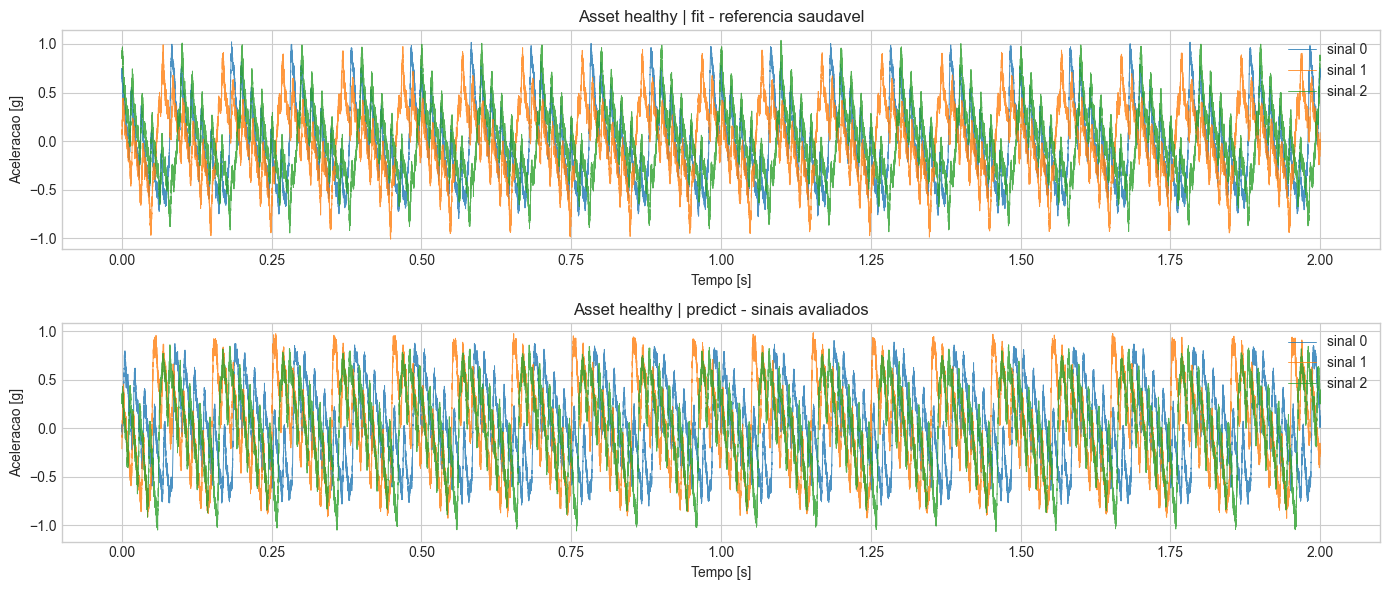

In [7]:
# visualização dos sinais de tempo para os assets healthy e starved.
def plotar_sinais_tempo(asset_id, titulo):
    fit = carregar_npz(asset_id, 'fit')
    pred = carregar_npz(asset_id, 'predict')

    fig, eixos = plt.subplots(2, 1, figsize=(14, 6), sharex=False)
    for eixo, split_nome, obj in [
        (eixos[0], 'fit - referencia saudavel', fit),
        (eixos[1], 'predict - sinais avaliados', pred),
    ]:
        quantidade = min(3, obj['data'].shape[0])
        for i in range(quantidade):
            tempo = np.arange(obj['data'].shape[1]) * obj['dt'][i]
            eixo.plot(tempo, obj['data'][i], lw=0.7, alpha=0.8, label=f'sinal {i}')
        eixo.set_title(f'{titulo} | {split_nome}')
        eixo.set_xlabel('Tempo [s]')
        eixo.set_ylabel('Aceleracao [g]')
        eixo.legend(loc='upper right')
    plt.tight_layout()


plotar_sinais_tempo(asset_healthy, 'Asset healthy')

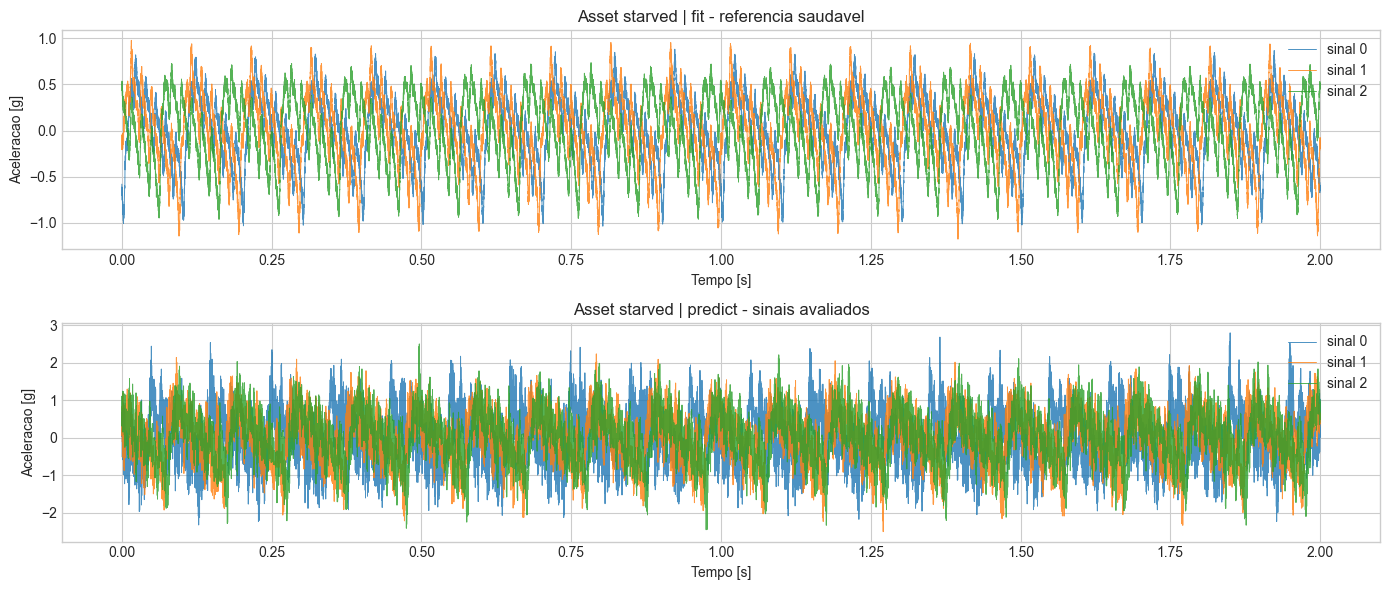

In [8]:
plotar_sinais_tempo(asset_starved, 'Asset starved')


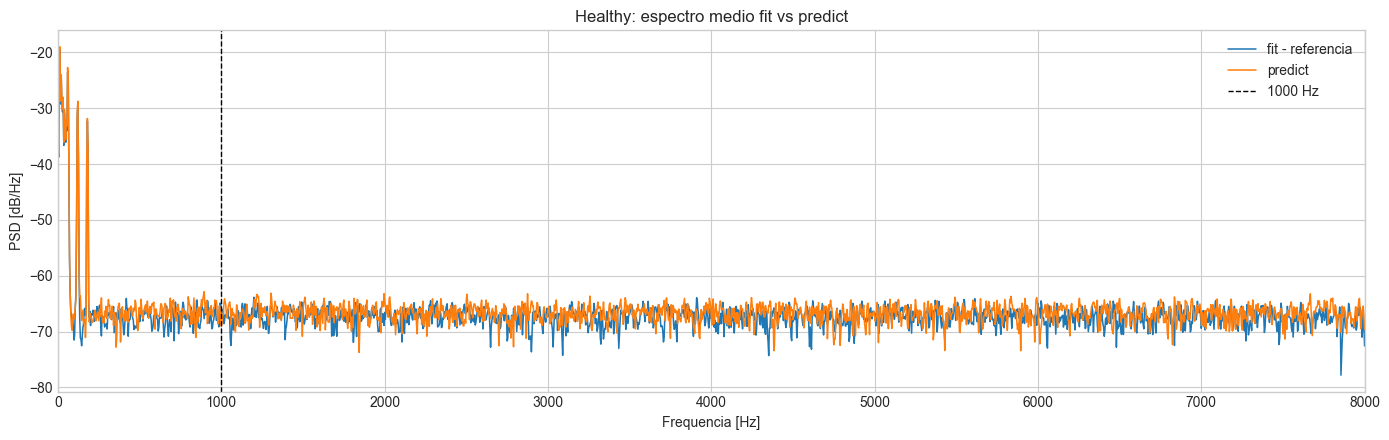

In [ ]:
def psd_welch(sinal, dt, nperseg=4096):
    fs = 1.0 / dt #frequencia de amostragem
    sinal = signal.detrend(sinal - np.mean(sinal), type='linear') #retirar tendencia linear do sinal
    nperseg = min(nperseg, len(sinal))
    freq, psd = signal.welch(
        sinal,
        fs=fs,
        window='hann',
        nperseg=nperseg,
        noverlap=nperseg // 2,
        scaling='density',
    ) #calculo da densidade espectral de potência usando o método de Welch
    return freq, psd


def espectro_medio(obj, max_sinais=20):
    n = obj['data'].shape[0]
    indices = np.linspace(0, n - 1, min(n, max_sinais), dtype=int)
    psds = []
    freq_ref = None
    for i in indices:
        freq, psd = psd_welch(obj['data'][i], obj['dt'][i])
        if freq_ref is None:
            freq_ref = freq
        psds.append(np.interp(freq_ref, freq, psd))
    return freq_ref, np.mean(psds, axis=0)


def plotar_fit_vs_predict_espectro(asset_id, titulo):
    fit = carregar_npz(asset_id, 'fit')
    pred = carregar_npz(asset_id, 'predict')
    freq_fit, psd_fit = espectro_medio(fit)
    freq_pred, psd_pred = espectro_medio(pred)

    fig, eixo = plt.subplots(figsize=(14, 4.5))
    eixo.plot(freq_fit, 10 * np.log10(psd_fit + EPS), lw=1.1, label='fit - referencia')
    eixo.plot(freq_pred, 10 * np.log10(psd_pred + EPS), lw=1.1, label='predict')
    eixo.axvline(FREQ_MINIMA_CARPET_HZ, color='black', ls='--', lw=1, label='1000 Hz')
    eixo.set_xlim(0, min(8000, freq_fit.max(), freq_pred.max()))
    eixo.set_title(titulo)
    eixo.set_xlabel('Frequencia [Hz]')
    eixo.set_ylabel('PSD [dB/Hz]')
    eixo.legend(loc='best')
    plt.tight_layout()


plotar_fit_vs_predict_espectro(asset_healthy, 'Healthy: espectro medio fit vs predict')

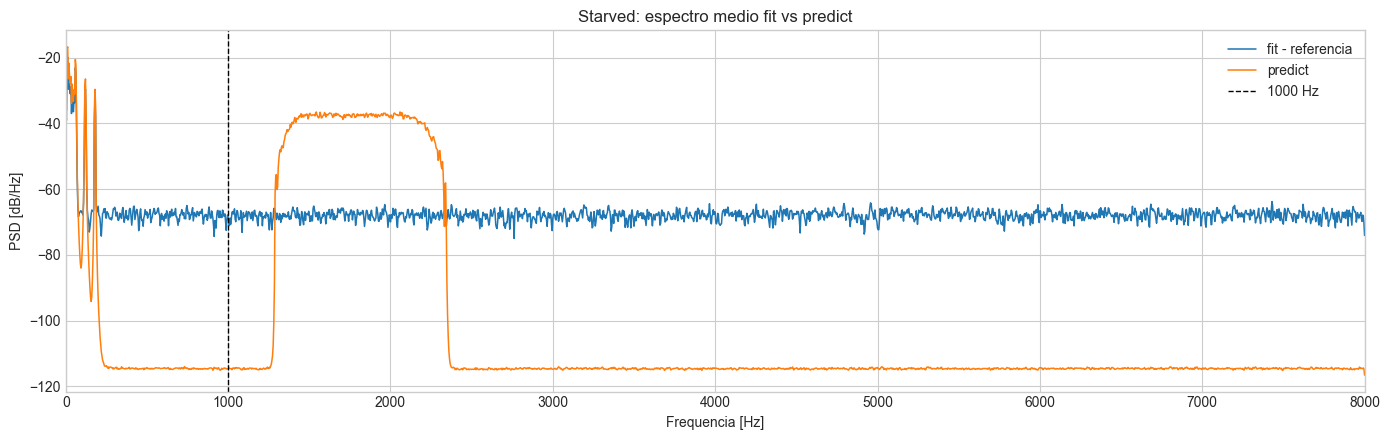

In [10]:
plotar_fit_vs_predict_espectro(asset_starved, 'Starved: espectro medio fit vs predict')